# Лабораторная работа 10. Spark

PySpark — это Python-обёртка над Apache Spark, который написан на Scala и работает на JVM. Без Java процесс Spark просто не запустится, независимо от того, установлен ли Python и PySpark. Поэтому заранее необходимо установить JAVA

In [ ]:
import os

JAVA_HOME = r"C:\Program Files\Java\jdk-17"
os.environ["JAVA_HOME"] = JAVA_HOME
os.environ["PATH"] = os.path.join(JAVA_HOME, "bin") + os.pathsep + os.environ.get("PATH", "")

print("JAVA_HOME:", os.environ["JAVA_HOME"])

JAVA_HOME: C:\Program Files\Java\jdk-21


In [40]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.master("local[*]").getOrCreate()
spark

### SparkSession

`SparkSession` — единая точка входа в PySpark, объединяющая контекст Spark, SQL и потоковую обработку. Параметр `local[*]` запускает Spark в локальном режиме, используя все доступные ядра процессора. Обычно Spark разворачивается на кластере (YARN, Kubernetes и др.) и данные хранятся в HDFS

## 1. Загрузка датасета Iris

### Описание датасета

**Iris** Содержит 150 наблюдений трёх видов ирисов: **Setosa**, **Versicolor** и **Virginica** (по 50 записей каждого вида). Для каждого цветка измерены 4 признака:

| Признак | Описание |
|---|---|
| `sepal_length` | Длина чашелистика |
| `sepal_width`  | Ширина чашелистика |
| `petal_length` | Длина лепестка |
| `petal_width`  | Ширина лепестка |

Столбец `variety` — целевая переменная (метка класса). Исходные имена содержали точки (`sepal.length` и др.), которые несовместимы с синтаксисом PySpark-выражений, поэтому они переименованы через `toDF`.

In [41]:
iris_df = spark.read.csv('iris.csv', inferSchema=True, header=True)
iris_df = iris_df.toDF('sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'variety')

iris_df.show(5)
iris_df.printSchema()

+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|variety|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| Setosa|
|         4.9|        3.0|         1.4|        0.2| Setosa|
|         4.7|        3.2|         1.3|        0.2| Setosa|
|         4.6|        3.1|         1.5|        0.2| Setosa|
|         5.0|        3.6|         1.4|        0.2| Setosa|
+------------+-----------+------------+-----------+-------+
only showing top 5 rows
root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (nullable = true)
 |-- petal_length: double (nullable = true)
 |-- petal_width: double (nullable = true)
 |-- variety: string (nullable = true)



## 2. Максимальное, минимальное и среднее значение 4-х параметров по каждому типу цветка

In [42]:
from pyspark.sql import functions as F

stats_df = iris_df.groupBy("variety").agg(
    F.max("sepal_length").alias("max_sepal_length"),
    F.min("sepal_length").alias("min_sepal_length"),
    F.round(F.avg("sepal_length"), 2).alias("avg_sepal_length"),

    F.max("sepal_width").alias("max_sepal_width"),
    F.min("sepal_width").alias("min_sepal_width"),
    F.round(F.avg("sepal_width"), 2).alias("avg_sepal_width"),

    F.max("petal_length").alias("max_petal_length"),
    F.min("petal_length").alias("min_petal_length"),
    F.round(F.avg("petal_length"), 2).alias("avg_petal_length"),

    F.max("petal_width").alias("max_petal_width"),
    F.min("petal_width").alias("min_petal_width"),
    F.round(F.avg("petal_width"), 2).alias("avg_petal_width"),
).orderBy("variety")

stats_df.show()

+----------+----------------+----------------+----------------+---------------+---------------+---------------+----------------+----------------+----------------+---------------+---------------+---------------+
|   variety|max_sepal_length|min_sepal_length|avg_sepal_length|max_sepal_width|min_sepal_width|avg_sepal_width|max_petal_length|min_petal_length|avg_petal_length|max_petal_width|min_petal_width|avg_petal_width|
+----------+----------------+----------------+----------------+---------------+---------------+---------------+----------------+----------------+----------------+---------------+---------------+---------------+
|    Setosa|             5.8|             4.3|            5.01|            4.4|            2.3|           3.43|             1.9|             1.0|            1.46|            0.6|            0.1|           0.25|
|Versicolor|             7.0|             4.9|            5.94|            3.4|            2.0|           2.77|             5.1|             3.0|           

### Интерпретация статистики

По агрегированным данным прослеживаются чёткие закономерности:

- **Setosa** имеет значительно меньшие лепестки (`petal_length` ≈ 1.46 см, `petal_width` ≈ 0.25 см), что делает этот вид легко отличимым от остальных.
- **Virginica** — самый крупный вид: наибольшая средняя длина чашелистика (6.59 см) и лепестка (5.55 см).
- **Versicolor** занимает промежуточное положение между Setosa и Virginica по всем четырём параметрам.

## 3. Точечные графики по каждой паре параметров

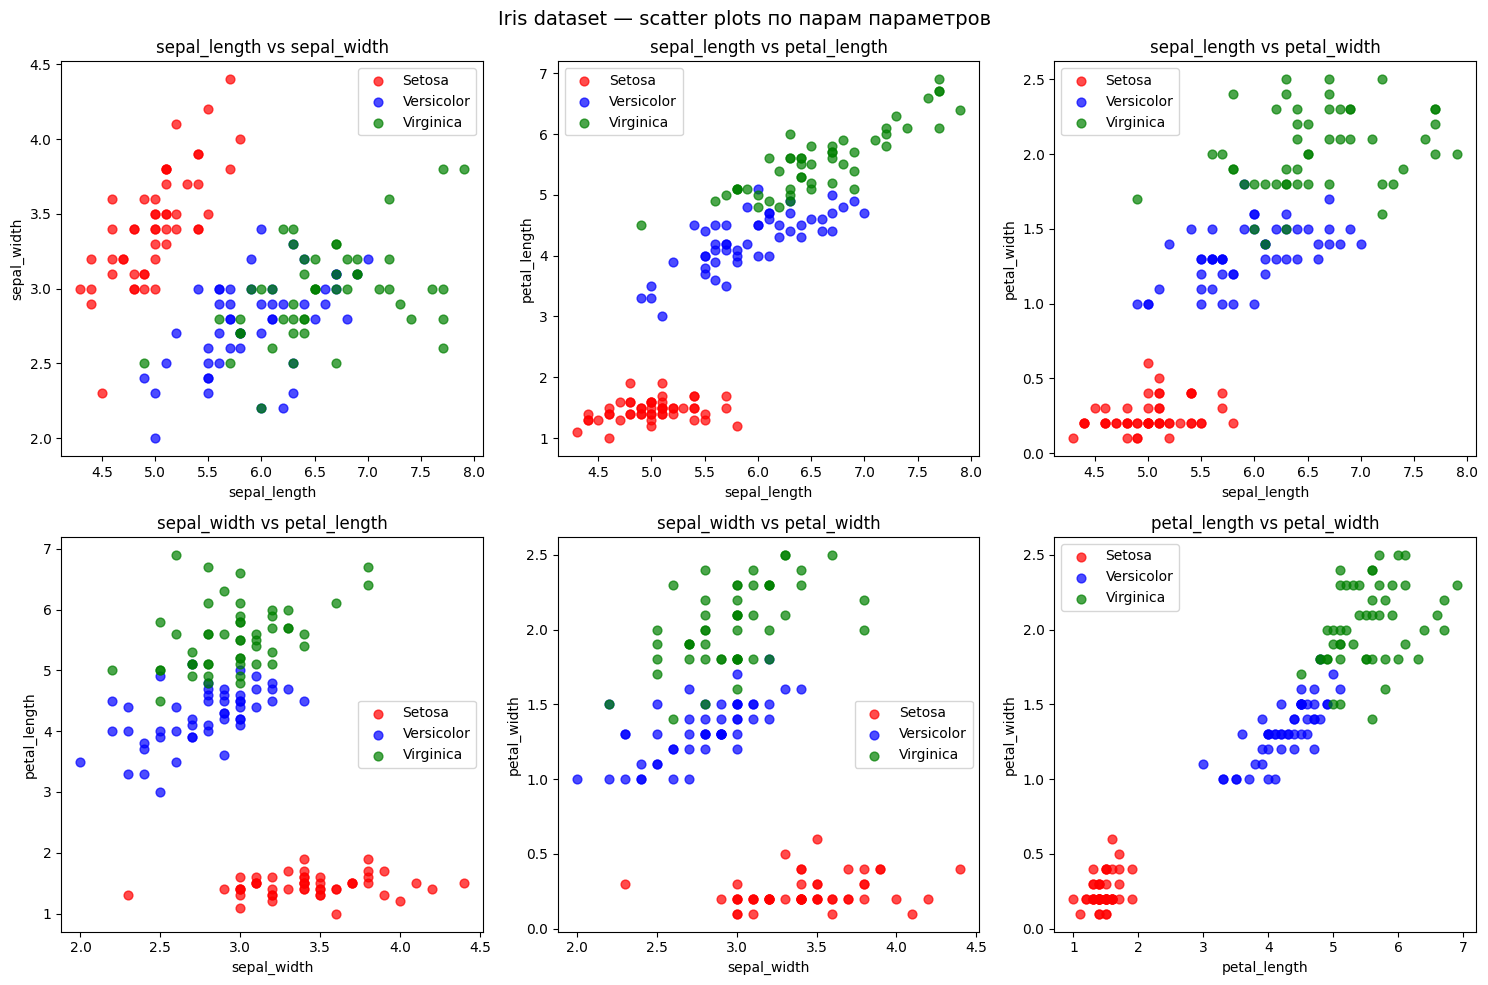

In [43]:
import matplotlib.pyplot as plt
%matplotlib inline

iris_pd = iris_df.toPandas()

params = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors = {'Setosa': 'red', 'Versicolor': 'blue', 'Virginica': 'green'}

# Все 6 пар параметров
pairs = [(params[i], params[j]) for i in range(len(params)) for j in range(i + 1, len(params))]

fig = plt.figure(figsize=(15, 10))

for idx, (x_col, y_col) in enumerate(pairs):
    plt.subplot(2, 3, idx + 1)
    for variety, color in colors.items():
        subset = iris_pd[iris_pd['variety'] == variety]
        plt.scatter(subset[x_col], subset[y_col], c=color, label=variety, alpha=0.7, s=40)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'{x_col} vs {y_col}')
    plt.legend()

plt.suptitle('Iris dataset — scatter plots по парам параметров', fontsize=14)
plt.tight_layout()
plt.show()

### Что показывают графики

На scatter plots видно, что **Setosa** (красные точки) образует компактное, хорошо изолированное облако — особенно на графиках с участием `petal_length` и `petal_width`. Это визуально подтверждает вывод из статистики: вид линейно отделим по параметрам лепестка

**Versicolor** и **Virginica** частично перекрываются на всех графиках, что означает: разделить их без ML-модели значительно сложнее

## 4. Правило разделения

По графику **petal_length vs petal_width** видно, что **Setosa** полностью отделяется от Versicolor и Virginica:
- у Setosa `petal_length` от 1.0 до 1.9 см
- у остальных `petal_length` > 3.0 см

**Правило:** ЕСЛИ `petal_length` < 2.5, ТО ЦВЕТОК СКОРЕЕ ВСЕГО ОТНОСИТСЯ К ТИПУ **Setosa**

## 5. Бинарная классификация: Setosa vs. Not Setosa

На основе правила из предыдущего раздела добавим колонку `prediction`. Простейший **бинарный классификатор**: задача сводится к разделению датасета на два класса вместо трёх. Одновременно формируем `true_label` — бинарную метку истинного класса — для последующего сравнения с предсказанием.

Используем `F.when(...).otherwise(...)` — PySpark-аналог условного выражения `CASE WHEN` из SQL.

In [44]:
iris_pred = iris_df.withColumn(
    'prediction',
    F.when(F.col('petal_length') < 2.5, 'Setosa').otherwise('Not Setosa')
).withColumn(
    'true_label',
    F.when(F.col('variety') == 'Setosa', 'Setosa').otherwise('Not Setosa')
)

iris_pred.select('petal_length', 'variety', 'true_label', 'prediction').show(150)

+------------+----------+----------+----------+
|petal_length|   variety|true_label|prediction|
+------------+----------+----------+----------+
|         1.4|    Setosa|    Setosa|    Setosa|
|         1.4|    Setosa|    Setosa|    Setosa|
|         1.3|    Setosa|    Setosa|    Setosa|
|         1.5|    Setosa|    Setosa|    Setosa|
|         1.4|    Setosa|    Setosa|    Setosa|
|         1.7|    Setosa|    Setosa|    Setosa|
|         1.4|    Setosa|    Setosa|    Setosa|
|         1.5|    Setosa|    Setosa|    Setosa|
|         1.4|    Setosa|    Setosa|    Setosa|
|         1.5|    Setosa|    Setosa|    Setosa|
|         1.5|    Setosa|    Setosa|    Setosa|
|         1.6|    Setosa|    Setosa|    Setosa|
|         1.4|    Setosa|    Setosa|    Setosa|
|         1.1|    Setosa|    Setosa|    Setosa|
|         1.2|    Setosa|    Setosa|    Setosa|
|         1.5|    Setosa|    Setosa|    Setosa|
|         1.3|    Setosa|    Setosa|    Setosa|
|         1.4|    Setosa|    Setosa|    

В таблице видно соответствие между `petal_length`, фактическим видом (`variety`), бинарной меткой (`true_label`) и предсказанием (`prediction`). Для первых 15 строк все записи — Setosa, и предсказание корректно совпадает. Проверим точность на полном датасете из 150 наблюдений.

## 6. Оценка качества предсказания

In [45]:
total   = iris_pred.count()
correct = iris_pred.filter(F.col('prediction') == F.col('true_label')).count()
wrong   = total - correct

print(f'Всего записей:       {total}')
print(f'Угадано правильно:   {correct} ({correct / total * 100:.1f}%)')
print(f'Угадано неправильно: {wrong}   ({wrong   / total * 100:.1f}%)')

print('\nПодробная разбивка:')
iris_pred.groupBy('true_label', 'prediction').count().orderBy('true_label').show()

Всего записей:       150
Угадано правильно:   150 (100.0%)
Угадано неправильно: 0   (0.0%)

Подробная разбивка:
+----------+----------+-----+
|true_label|prediction|count|
+----------+----------+-----+
|Not Setosa|Not Setosa|  100|
|    Setosa|    Setosa|   50|
+----------+----------+-----+



### Вывод

Правило `petal_length < 2.5` даёт **100% точность** на датасете Iris для задачи бинарного разделения Setosa от остальных видов